In [2]:
import random
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd

import pyarrow as pa
import pyarrow.parquet as pq

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf

import optuna

import seaborn as sns

from stage1 import lasso_rolling_window, calculate_r_squared
from stage2 import estimate_kappa_curve_fit, compute_alm_returns, compute_stage2_r_squared
from grid_search import grid_search, estimate_single_config

import plot_style
plot_style.apply()


In [3]:
# load feature matrix and response variable
feature_matrix = pd.read_csv("../../data/merged_return_topic_data.csv", index_col=0, parse_dates=True)
response_variables = pd.read_csv("../../data/response.csv", index_col=0, parse_dates=True)
stock_data = pd.read_csv("../../data/X.csv", index_col=0, parse_dates=True)

Summary Statistics of Data


In [4]:
## seperate topic from stock data ##

# boolean mask: columns that contain any letter
has_letters = stock_data.columns.str.contains('[a-zA-Z]')

# topic-related columns (strings, topic names, etc.)
topic_data = stock_data.loc[:, has_letters].copy()

# stock-related columns (numeric identifiers, PERMNOs, etc.)
stock_data_only = stock_data.loc[:, ~has_letters].copy()

In [5]:
## Functions to create Summary Data Table ##

def to_ar1_innovations(X: pd.DataFrame, min_obs: int = 30, 
                       print_summary: bool = True, return_coefs: bool = False):
    """Return AR(1) residuals for each column of X."""
    innovations = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
    coefs = {}

    for col in X.columns:
        s = pd.to_numeric(X[col], errors='coerce')
        df = pd.DataFrame({'x': s, 'lag': s.shift(1)}).dropna()
        
        if len(df) < min_obs or df['x'].nunique() < 3:
            continue
            
        model = sm.OLS(df['x'], sm.add_constant(df['lag'])).fit()
        innovations.loc[df.index, col] = model.resid
        coefs[col] = model.params['lag']

    coefs = pd.Series(coefs)

    if print_summary and not coefs.empty:
        stats = pd.Series({
            'N': len(coefs), 'Mean': coefs.mean(), 'Std': coefs.std(),
            'Min': coefs.min(), 'P5': coefs.quantile(0.05),
            'Median': coefs.median(), 'P95': coefs.quantile(0.95),
            'Max': coefs.max()
        })
        print(stats.to_frame().T.to_latex(float_format='%.4f'))

    return (innovations, coefs) if return_coefs else innovations


def panel_construction(stock_data: pd.DataFrame) -> pd.DataFrame:
    """Panel A: log stock return statistics."""
    r = np.log1p(stock_data).stack()
    
    stats = pd.DataFrame({
        'Mean': [r.mean()], 'Std': [r.std()], 'Min': [r.min()], 
        'Max': [r.max()], 'Skew': [r.skew()], 'Kurt': [r.kurtosis()], 
        'Obs': [r.count()]
    })
    
    print(stats.to_latex(float_format='%.4f'))
    return stats


def panel_b_ar1_phi(ar1_phi: pd.Series) -> pd.DataFrame:
    """Panel B: AR(1) coefficient statistics."""
    s = pd.to_numeric(ar1_phi, errors='coerce').dropna()
    
    stats = pd.DataFrame({
        'Mean': [s.mean()], 'Std': [s.std()], 'Min': [s.min()],
        'Max': [s.max()], 'Skew': [s.skew()], 'Kurt': [s.kurtosis()],
        'Obs': [s.count()]
    }, index=[r'AR(1) coefficient $\phi$'])
    
    print(stats.to_latex(float_format='%.4f'))
    return stats


## Functions to get correlation matrix and table ##


def plot_corr_heatmap_png(df, output_file="correlation_heatmap", figsize=(10, 10), dpi=600):
    corr = df.apply(pd.to_numeric, errors="coerce").dropna(axis=1, how="all").corr()
    
    sns.set_theme(style="white", font="serif")
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True, 
                cbar_kws={"label": "Correlation"})
    
    plt.savefig(f"{output_file}.png", dpi=dpi, bbox_inches="tight")
    plt.savefig(f"{output_file}.pdf", bbox_inches="tight")
    plt.close()


def cross_lag_correlation_summary(df, lags=(1, 2, 3)):
    X = df.apply(pd.to_numeric, errors="coerce").dropna(axis=1, how="all")
    results = []
    
    for k, l in product(lags, lags):
        Xk, Xl = X.shift(k), X.shift(l)
        valid = ~(Xk.isna().any(axis=1) | Xl.isna().any(axis=1))
        Xk_v, Xl_v = Xk[valid], Xl[valid]
        
        if len(Xk_v) < 2:
            results.append([k, l, np.nan, np.nan, np.nan, np.nan])
            continue
        
        Xk_std = (Xk_v - Xk_v.mean()) / Xk_v.std()
        Xl_std = (Xl_v - Xl_v.mean()) / Xl_v.std()
        corr = (Xk_std.values.T @ Xl_std.values) / len(Xk_std)
        corrs = corr[~np.eye(len(corr), dtype=bool)]
        corrs = corrs[~np.isnan(corrs)]
        
        if len(corrs) == 0:
            results.append([k, l, np.nan, np.nan, np.nan, np.nan])
        else:
            results.append([k, l, corrs.mean(), np.median(corrs), 
                          np.abs(corrs).max(), np.percentile(np.abs(corrs), 95)])
    
    return pd.DataFrame(results, columns=["k", "l", "Mean", "Median", "Max |r|", "P95 |r|"])

In [6]:
print("Topic data summary:")
panel_a = panel_construction(topic_data)
print("-----------------------------------------------------------------------")
print("Retun data summary:")
panel_a = panel_construction(stock_data_only)
print("-----------------------------------------------------------------------")
print("AR1 coefficients summary:")
X_innov, ar1_phi = to_ar1_innovations(topic_data, return_coefs=True)

Topic data summary:
\begin{tabular}{lrrrrrrr}
\toprule
 & Mean & Std & Min & Max & Skew & Kurt & Obs \\
\midrule
0 & 0.0055 & 0.0041 & 0.0000 & 0.1161 & 3.6616 & 33.3613 & 340020 \\
\bottomrule
\end{tabular}

-----------------------------------------------------------------------
Retun data summary:
\begin{tabular}{lrrrrrrr}
\toprule
 & Mean & Std & Min & Max & Skew & Kurt & Obs \\
\midrule
0 & 0.0003 & 0.0206 & -1.9641 & 2.0509 & -0.5867 & 101.9167 & 3060180 \\
\bottomrule
\end{tabular}

-----------------------------------------------------------------------
AR1 coefficients summary:
\begin{tabular}{lrrrrrrrr}
\toprule
 & N & Mean & Std & Min & P5 & Median & P95 & Max \\
\midrule
0 & 180.0000 & 0.1427 & 0.1404 & -0.0895 & -0.0020 & 0.0992 & 0.4290 & 0.7635 \\
\bottomrule
\end{tabular}



Corrleation Matrices and Coefficients

In [7]:
plot_corr_heatmap_png(X_innov, output_file="corr_topics_heatmap.png")

RuntimeError: latex was not able to process the following string:
b'M&A'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-02-22>
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2023/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/graphics/keyval.sty)

RuntimeError: latex was not able to process the following string:
b'M&A'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-02-22>
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2023/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/graphics/keyval.sty)

<Figure size 1000x1000 with 2 Axes>

In [8]:
summary_df = cross_lag_correlation_summary(X_innov, lags=(1, 3, 5, 7, 9, 11))
print(summary_df.to_latex(index=False, float_format="%.4f"))

\begin{tabular}{rrrrrr}
\toprule
k & l & Mean & Median & Max |r| & P95 |r| \\
\midrule
1 & 1 & -0.0003 & -0.0037 & 0.5453 & 0.0904 \\
1 & 3 & 0.0003 & -0.0001 & 0.2147 & 0.0567 \\
1 & 5 & 0.0002 & -0.0002 & 0.1653 & 0.0572 \\
1 & 7 & 0.0001 & -0.0004 & 0.1592 & 0.0567 \\
1 & 9 & 0.0002 & 0.0000 & 0.1514 & 0.0552 \\
1 & 11 & 0.0004 & 0.0001 & 0.2656 & 0.0598 \\
3 & 1 & 0.0003 & -0.0001 & 0.2147 & 0.0567 \\
3 & 3 & -0.0003 & -0.0037 & 0.5456 & 0.0904 \\
3 & 5 & 0.0003 & -0.0001 & 0.2146 & 0.0568 \\
3 & 7 & 0.0002 & -0.0001 & 0.1660 & 0.0573 \\
3 & 9 & 0.0001 & -0.0004 & 0.1594 & 0.0568 \\
3 & 11 & 0.0002 & -0.0001 & 0.1513 & 0.0552 \\
5 & 1 & 0.0002 & -0.0002 & 0.1653 & 0.0572 \\
5 & 3 & 0.0003 & -0.0001 & 0.2146 & 0.0568 \\
5 & 5 & -0.0003 & -0.0037 & 0.5455 & 0.0903 \\
5 & 7 & 0.0003 & -0.0000 & 0.2116 & 0.0568 \\
5 & 9 & 0.0002 & -0.0001 & 0.1658 & 0.0572 \\
5 & 11 & 0.0001 & -0.0004 & 0.1603 & 0.0566 \\
7 & 1 & 0.0001 & -0.0004 & 0.1592 & 0.0567 \\
7 & 3 & 0.0002 & -0.0001 & 0.1660 &

First Stage results

In [9]:
# load estimation results
# summaries = pd.read_parquet('stage1_stage2_summaries.parquet')
# details = pd.read_parquet('stage1_stage2_details.parquet')
import pickle

summary_per_stock = pickle.load(open("summary_per_stock.pkl", "rb"))
details_per_stock = pickle.load(open("details_per_stock.pkl", "rb"))

#keep only keys for which summary_per_stock is not None
summary_per_stock = {k: v for k, v in summary_per_stock.items() if v is not None}
details_per_stock = {k: v for k, v in details_per_stock.items() if k in summary_per_stock}

#make summaries dataframe, key will be the index, then for each key in value dictionary, make a column
summaries = pd.DataFrame.from_dict(summary_per_stock, orient='index')


First stage estimation results table

In [11]:
def summarize(s):
    #drop nas
    s = s.dropna()
    return pd.Series({
        "mean": s.mean(), "std": s.std(), "median": s.median(),
        "min": s.min(), "max": s.max(), "p05": s.quantile(0.05), "p95": s.quantile(0.95)
    })

# R2s
r2_in = summarize(summaries["r2_insample_stage1"])
r2_oos = summarize(summaries["r2_oos_stage1"])

# # Betas (absolute non-zero)
# for key, details in details_per_stock.items():




#     beta_cols = [c for c in details.columns if c.startswith("Lasso_")]
#     beta_vals = details[beta_cols].to_numpy().ravel()
#     beta_stats = summarize(pd.Series(np.abs(beta_vals[beta_vals != 0])))

# # Selection rate
# sel_rate = details.groupby("target_column")["num_nonzero_recalc"].apply(lambda x: (x > 0).mean())
# sel_rate_stats = summarize(sel_rate)

# Table
out = pd.DataFrame([r2_in, r2_oos], #, beta_stats, sel_rate_stats],
                   index=["In-sample $R^2$", "Out-of-sample $R^2$"]) #, "$\beta$ absolute value", "Selection rate"]

print(out.to_latex(float_format="%.4f"))



\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & median & min & max & p05 & p95 \\
\midrule
In-sample $R^2$ & 0.1056 & 0.1149 & 0.0756 & -0.0009 & 0.5041 & -0.0007 & 0.3161 \\
Out-of-sample $R^2$ & -0.0231 & 0.0344 & -0.0116 & -0.1788 & 0.0037 & -0.0766 & -0.0003 \\
\bottomrule
\end{tabular}



In [12]:
#plot number of non-zero betas over time
#we plot the average in bold and p95 and p05 as shaded area
time_index = details_per_stock[list(details_per_stock.keys())[0]].index.unique().sort_values()



all_nonzero = pd.DataFrame(index=time_index)
for key, details in details_per_stock.items():
    nonzero_counts = details["num_nonzero_coefficients"]
    all_nonzero[key] = nonzero_counts

In [13]:
#compute the average, p05 and p95 over stocks
mean_nonzero = all_nonzero.mean(axis=1)
p05_nonzero = all_nonzero.quantile(0.05, axis=1)
p95_nonzero = all_nonzero.quantile(0.95, axis=1)

In [14]:
dates = stock_data_only.index
len(dates)

1889

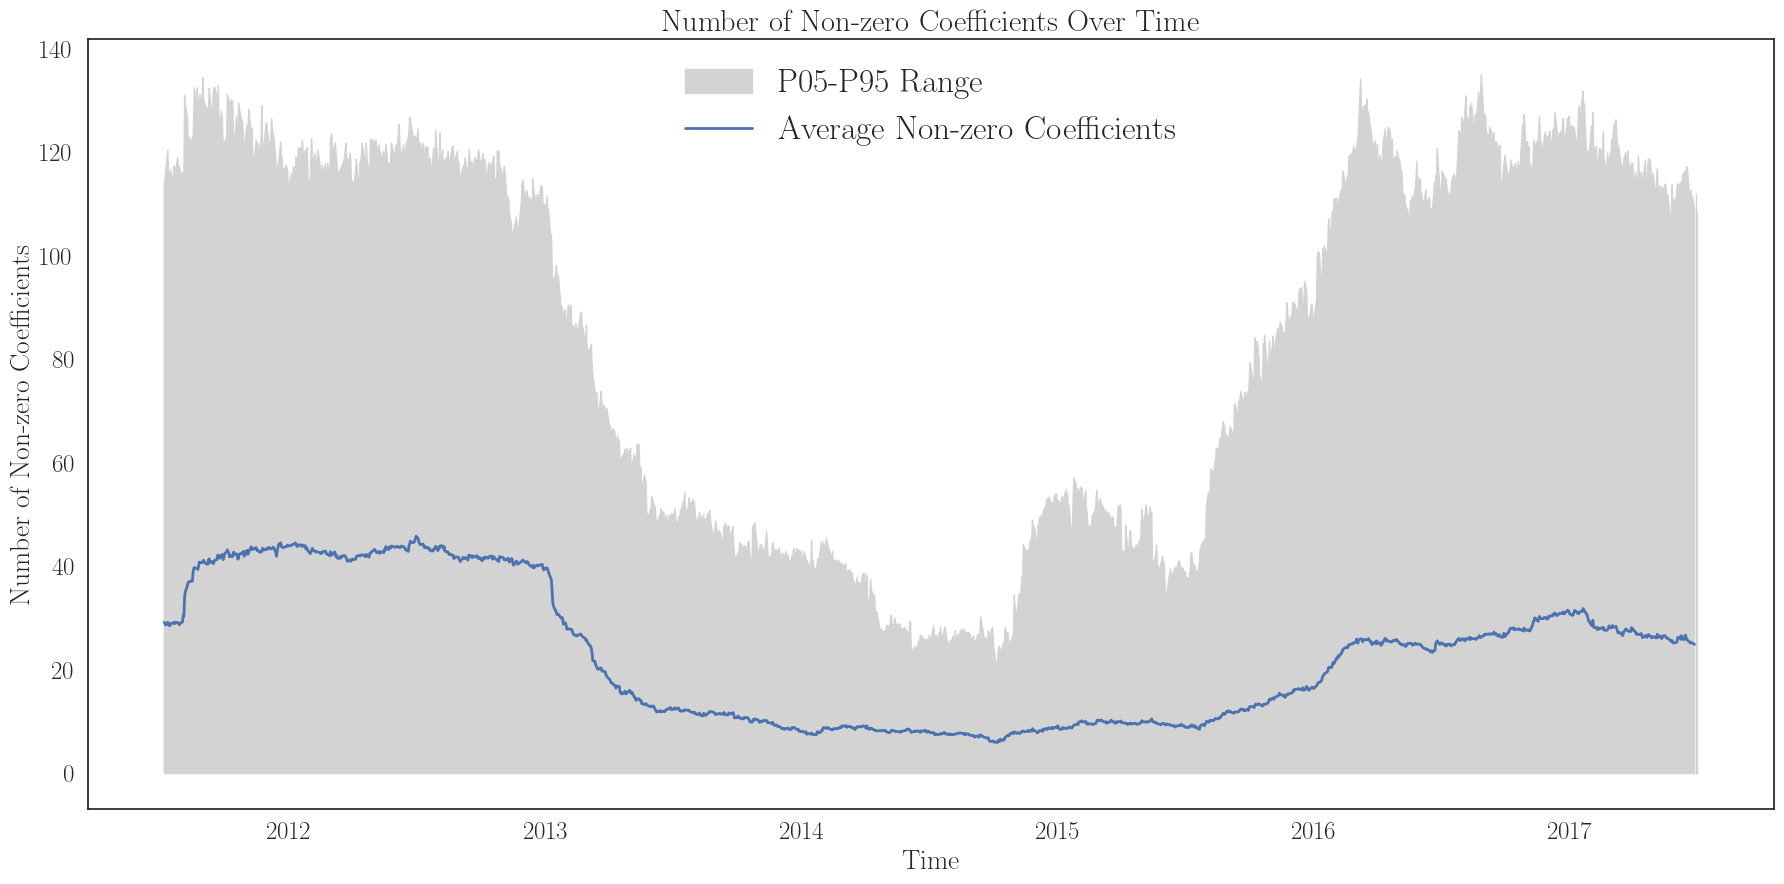

In [15]:
#plot the average, p05 and p95

#increase font size for legend
plt.rcParams.update({"legend.fontsize": 24,
})

#increse font size for axes
plt.rcParams.update({"axes.labelsize": 20,
                     "axes.titlesize": 22,
                     "xtick.labelsize": 18,
                     "ytick.labelsize": 18,
})

#first we retrieve the actual data from the stock_data_only dataframe
dates = stock_data_only.index

#we remove the first dates until we match the proper length len(details_per_stock['10065'])
dates = dates[-len(details_per_stock['10065']):]

plt.figure(figsize=(18, 9))
plt.fill_between(dates, p05_nonzero, p95_nonzero, color='lightgray', label='P05-P95 Range')
plt.plot(dates, mean_nonzero, linewidth=2, label='Average Non-zero Coefficients')
plt.title('Number of Non-zero Coefficients Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Non-zero Coefficients')
plt.legend()
plt.tight_layout()

#save figure
#plt.savefig("/Users/tommasodifrancesco/Desktop/Lasso_paper/Manuscripts/manuscript/figures/nonzero_coefficients_over_time.png", dpi=600, bbox_inches="tight")

plt.show()



Second stage estimation results

In [ ]:
#first we take into considerations only case in which stage 2 t-stat is larger than 1.96
positive_tstat_mask = summaries['kappa_tstat'] > 1.96
positive_summaries = summaries[positive_tstat_mask]

#print the proportion of stocks with positive stage 2 t-stat
print("Proportion of stocks with significant stage 2 t-stat: ", len(positive_summaries) / len(summaries))




Proportion of stocks with significant stage 2 t-stat:  0.25


In [18]:
def summarize(s):
    return pd.Series({
        "mean": s.mean(), "std": s.std(), "median": s.median(),
        "min": s.min(), "max": s.max(), "p05": s.quantile(0.05), "p95": s.quantile(0.95)
    })

# Stage 2 stats
r2_in_2 = summarize(pd.to_numeric(positive_summaries["r2_insample_stage2"], errors="coerce"))
r2_oos_2 = summarize(pd.to_numeric(positive_summaries["r2_oos_stage2"], errors="coerce"))
kappa = summarize(pd.to_numeric(positive_summaries["kappa"], errors="coerce"))
kappa_t = summarize(pd.to_numeric(positive_summaries["kappa_tstat"], errors="coerce"))

# Table
out_stage2 = pd.DataFrame([r2_in_2, r2_oos_2, kappa, kappa_t],
                          index=["In-sample $R^2$ ", "Out-of-sample $R^2$", "$\hat{\kappa}$", "$t$-statistic of $\hat{\kappa}$"])

print(out_stage2.to_latex(float_format="%.4f"))

\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & median & min & max & p05 & p95 \\
\midrule
In-sample $R^2$  & 0.0016 & 0.0011 & 0.0016 & 0.0001 & 0.0038 & 0.0002 & 0.0033 \\
Out-of-sample $R^2$ & -0.0021 & 0.0064 & -0.0010 & -0.0092 & 0.0145 & -0.0088 & 0.0065 \\
$\hat{\kappa}$ & 0.6435 & 0.2718 & 0.6637 & 0.1311 & 0.9711 & 0.2337 & 0.9683 \\
$t$-statistic of $\hat{\kappa}$ & 9.5058 & 12.7404 & 4.7980 & 1.9954 & 44.1949 & 2.0958 & 34.4050 \\
\bottomrule
\end{tabular}



<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_36201/1479291098.py:15: SyntaxWarning: invalid escape sequence '\h'
  index=["In-sample $R^2$ ", "Out-of-sample $R^2$", "$\hat{\kappa}$", "$t$-statistic of $\hat{\kappa}$"])
/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_36201/1479291098.py:15: SyntaxWarning: invalid escape sequence '\h'
  index=["In-sample $R^2$ ", "Out-of-sample $R^2$", "$\hat{\kappa}$", "$t$-statistic of $\hat{\kappa}$"])


Plot the return volatility of each stock against the average number of non-zero predictors in each window. 

In [ ]:
stock_cols = [col for col in stock_data.columns if str(col).isdigit()]
stock_data = stock_data[stock_cols]

# for column, calculate the standard deviation
variances = stock_data.var()
# calculate avg number of non-zero coefficients per stock
# identify LASSO coefficient columns (exclude intercept)
coef_cols = [c for c in details.columns if c.startswith("Lasso_")]

details["num_nonzero_recalc"] = (
    details[coef_cols]
    .notna()                # ignore NaNs
    .mul(details[coef_cols] != 0)
    .sum(axis=1)
)

# average per stock
avg_nonzero_df = (
    details
    .groupby("target_column")["num_nonzero_recalc"]
    .mean()
    .reset_index()
    .rename(columns={
        "target_column": "target_stock",
        "num_nonzero_recalc": "avg_nonzero_coefficients"
    })
)

plot_num_selected = avg_nonzero_df.merge(variances.rename("variance"), left_on="target_stock", right_index=True)

# Output path
out_dir = r"C:\Users\jonat\Lasso_paper\Manuscripts\manuscript\figures"
os.makedirs(out_dir, exist_ok=True)

# Figure
plt.figure(figsize=(6, 4))

plt.scatter(
    plot_num_selected["variance"],
    plot_num_selected["avg_nonzero_coefficients"],
    s=18,
    alpha=0.6,
    color="black",
    edgecolor="none"
)

plt.xlabel("Stock Return Volatility", fontsize=11)
plt.ylabel("Average Number of Selected Predictors", fontsize=11)

plt.tick_params(axis="both", which="major", labelsize=10)
plt.grid(False)

plt.tight_layout()

# Save
plt.savefig(os.path.join(out_dir, "avg_nonzero_coefficients_vs_volatility.pdf"))
plt.close()

NameError: name 'stock_data' is not defined

Plot the number of stocks on each day that have one or more non-zero coefficients. 

In [ ]:
# Check what columns are available
print(details.columns.tolist())

In [ ]:
# Aggregate: count stocks with non-zero coefficients per date
stock_count = details.groupby("date")["num_nonzero_recalc"].apply(lambda x: (x > 0).sum())

# Remove leading zeros and ensure we end at last observation
stock_count = stock_count[stock_count > 0]
stock_count = stock_count[stock_count.index.notna()]

# Determine total number of stocks in sample
# Option 1: If you have a 'stock_id' or similar column
total_stocks = details['target_column'].nunique()  # Replace 'stock_id' with your actual column name

# Option 2: If you know the theoretical maximum (e.g., all stocks in your universe)
# total_stocks = 500  # Replace with your actual number

# Plot
plt.figure(figsize=(6, 4))
plt.bar(stock_count.index, stock_count.values, color="black", width=1, edgecolor="none", alpha=0.6)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Number of Stocks with Non-Zero Coefficients", fontsize=11)
plt.tick_params(axis="both", which="major", labelsize=10)
plt.grid(False)
plt.xlim(stock_count.index.min(), stock_count.index.max())
plt.ylim(0, total_stocks)  # Set y-axis to go from 0 to total stocks
plt.tight_layout()

# Save
out_dir = r"C:\Users\jonat\Lasso_paper\Manuscripts\manuscript\figures"
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, "nonzero_stocks_over_time.pdf"))
plt.close()

Plot of % of all coefficients that are active for some stock on each day.

In [ ]:
# Calculate % of active coefficients per stock-date
import os


coef_cols = [c for c in details.columns if c.startswith("Lasso_")]
details["n_active"] = (details[coef_cols] != 0).sum(axis=1)
details["pct_active"] = details["n_active"] / len(coef_cols) * 100

# Filter: only stocks with at least 1 active coefficient
details_active = details[details["n_active"] > 0].copy()

# Average per date (only over stocks with ≥1 active coefficient)
pct_active_by_date = details_active.groupby("date")["pct_active"].mean()
pct_active_by_date = pct_active_by_date[pct_active_by_date.index.notna()]

# Plot
plt.figure(figsize=(6, 4))
plt.bar(pct_active_by_date.index, pct_active_by_date.values, color="black", 
        width=1, edgecolor="none", alpha=0.6)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Percentage of Coefficients Selected (%)", fontsize=11)
plt.tick_params(axis="both", which="major", labelsize=10)
plt.grid(False)
plt.xlim(pct_active_by_date.index.min(), pct_active_by_date.index.max())
plt.tight_layout()

out_dir = r"C:\Users\jonat\Lasso_paper\Manuscripts\manuscript\figures"
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, "pct_active_coefficients_conditional.pdf"))
plt.close()